# CIFAR-10: Classical ML vs Dense Neural Networks vs CNNs

This notebook is the main **CIFAR-10 model-comparison study**. It compares classical machine learning, PCA-based features, dense neural networks, compact CNNs, deeper VGG-style CNNs, and increasingly regularized or augmented CNN variants.

### Main comparisons
- Classical ML on raw pixels vs PCA features
- Classical ML vs dense neural networks
- Dense networks vs CNNs
- Compact CNN vs deeper VGG-style CNNs
- Baseline CNN vs dropout and batch-normalized CNNs
- Original vs mirrored training
- Fixed learning rate vs scheduled learning rate
- Baseline training vs generator-based and layer-based augmentation
- Original vs mirrored vs ensemble test-time prediction

## 1. Setup

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input, Dense, Flatten, Conv2D, MaxPooling2D,
    BatchNormalization, Dropout, Activation,
    RandomFlip, RandomRotation, Resizing, RandomCrop,
    RandomTranslation, RandomZoom, RandomContrast,
    RandomBrightness, RandAugment,
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
def plot_results(history):
    fig, ax = plt.subplots(ncols=2, figsize=(12, 4))

    ax[0].plot(history.history["accuracy"], label="train")
    ax[0].plot(history.history["val_accuracy"], label="validation")
    ax[0].set_title("Accuracy")
    ax[0].legend()

    ax[1].plot(history.history["loss"], label="train")
    ax[1].plot(history.history["val_loss"], label="validation")
    ax[1].set_title("Loss")
    ax[1].legend()

    plt.show()


def evaluate_model(model_class, X_train, y_train, X_test, y_test):
    model = model_class()
    model.fit(X_train, y_train.ravel())
    pred = model.predict(X_test)
    return accuracy_score(y_test.ravel(), pred)

## 2. Classical ML Baselines on Raw Pixels

In [3]:
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = tf.keras.datasets.cifar10.load_data()

x_train_norm = x_train_raw.astype("float32") / 255.0
x_test_norm = x_test_raw.astype("float32") / 255.0

# Use every fifth image for the classical baselines to keep runtime manageable.
X_train_classical = x_train_norm[::5].reshape(-1, 32 * 32 * 3)
y_train_classical = y_train_raw[::5]

X_test_classical = x_test_norm[::5].reshape(-1, 32 * 32 * 3)
y_test_classical = y_test_raw[::5]

print("Classical training matrix:", X_train_classical.shape)
print("Classical test matrix:", X_test_classical.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1787s 10us/step
Classical training matrix: (10000, 3072)
Classical test matrix: (2000, 3072)


In [4]:
models = [
    KNeighborsClassifier,
    RandomForestClassifier,
    MultinomialNB,
    DecisionTreeClassifier,
    LogisticRegression,
    SVC,
]

model_names = [
    "K-Nearest Neighbors",
    "Random Forest",
    "Multinomial Naive Bayes",
    "Decision Tree",
    "Logistic Regression",
    "Support Vector Classifier",
]

classical_accuracies = []

for model_class, name in zip(models, model_names):
    print("Evaluating", name)

    acc = evaluate_model(
        model_class,
        X_train_classical,
        y_train_classical,
        X_test_classical,
        y_test_classical,
    )

    classical_accuracies.append(acc)
    print("Accuracy = {:.4f}".format(acc))

best = int(np.argmax(classical_accuracies))

print("\nBest model:", model_names[best])
print("Accuracy = {:.4f}".format(classical_accuracies[best]))

Evaluating K-Nearest Neighbors
Accuracy = 0.2965
Evaluating Random Forest
Accuracy = 0.3960
Evaluating Multinomial Naive Bayes
Accuracy = 0.2885
Evaluating Decision Tree
Accuracy = 0.2530
Evaluating Logistic Regression


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy = 0.3765
Evaluating Support Vector Classifier
Accuracy = 0.4805

Best model: Support Vector Classifier
Accuracy = 0.4805


A prior run of the subsampled raw-pixel baselines reached **0.4805 accuracy** with the Support Vector Classifier.

## 3. Raw-Pixel SVC vs PCA + SVC

In [5]:
def svm_pca(n_components):
    pca = PCA(
        n_components=n_components,
        svd_solver="randomized",
        whiten=True,
        random_state=42,
    )

    X_train_pca = pca.fit_transform(X_train_classical)
    X_test_pca = pca.transform(X_test_classical)

    model = SVC()
    model.fit(X_train_pca, y_train_classical.ravel())

    pred = model.predict(X_test_pca)

    return accuracy_score(y_test_classical.ravel(), pred)


component_candidates = list(range(1, 150))
pca_svc_accuracy = np.array([
    svm_pca(n_components)
    for n_components in component_candidates
])

best_idx = int(np.argmax(pca_svc_accuracy))
best_components = component_candidates[best_idx]

print("Best number of components:", best_components)
print("Best SVC accuracy:", pca_svc_accuracy[best_idx])

Best number of components: 59
Best SVC accuracy: 0.4875


The original component sweep found its best score around **75 PCA components**, with accuracy near **0.4885**.

## 4. Classical Models: Raw Pixels vs PCA

In [6]:
n_components = 86

pca = PCA(
    n_components=n_components,
    svd_solver="randomized",
    whiten=True,
    random_state=42,
)

X_train_pca = pca.fit_transform(X_train_classical)
X_test_pca = pca.transform(X_test_classical)

print("PCA training matrix:", X_train_pca.shape)
print("PCA test matrix:", X_test_pca.shape)

pca_models = [
    KNeighborsClassifier,
    RandomForestClassifier,
    DecisionTreeClassifier,
    LogisticRegression,
    SVC,
]

pca_model_names = [
    "K-Nearest Neighbors",
    "Random Forest",
    "Decision Tree",
    "Logistic Regression",
    "Support Vector Classifier",
]

for model_class, name in zip(pca_models, pca_model_names):
    print("Evaluating", name)

    acc = evaluate_model(
        model_class,
        X_train_pca,
        y_train_classical,
        X_test_pca,
        y_test_classical,
    )

    print("Accuracy = {:.4f}".format(acc))

PCA training matrix: (10000, 86)
PCA test matrix: (2000, 86)
Evaluating K-Nearest Neighbors
Accuracy = 0.2600
Evaluating Random Forest
Accuracy = 0.4170
Evaluating Decision Tree
Accuracy = 0.2410
Evaluating Logistic Regression
Accuracy = 0.3895
Evaluating Support Vector Classifier
Accuracy = 0.4830


## 5. Classical ML vs Dense Neural Network

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 500)            │     1,536,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 500)            │       250,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,792,010 (6.84 MB)

 Trainable params: 1,792,010 (6.84 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.2941 - loss: 1.9886 - val_accuracy: 0.3718 - val_loss: 1.7793
Epoch 2/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3909 - loss: 1.7088 - val_accuracy: 0.4073 - val_loss: 1.6600
Epoch 3/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4255 - loss: 1.6174 - val_accuracy: 0.4413 - val_loss: 1.5930
Epoch 4/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4465 - loss: 1.5553 - val_accuracy: 0.4405 - val_loss: 1.5896
Epoch 5/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4670 - loss: 1.5009 - val_accuracy: 0.4500 - val_loss: 1.5434
Epoch 6/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4783 - loss: 1.4673 - val_accuracy: 0.4788 - val_loss: 1.4741
Epoch 7/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4924 - loss: 1.4261 - val_accuracy: 0.4790 - val_loss: 1.4652
Epoch 8/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5037 - loss: 1.3984 - val_ac

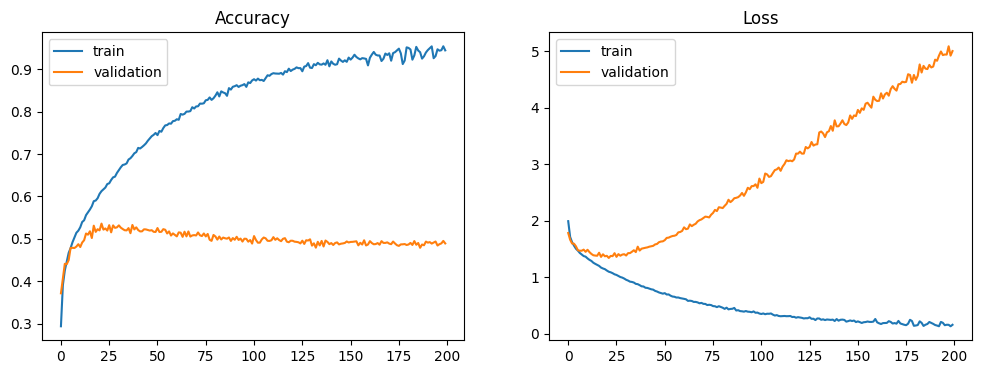

In [7]:
X_train_dense = x_train_norm.reshape(x_train_norm.shape[0], -1)
X_test_dense = x_test_norm.reshape(x_test_norm.shape[0], -1)

y_train_oh = tf.keras.utils.to_categorical(y_train_raw, 10)
y_test_oh = tf.keras.utils.to_categorical(y_test_raw, 10)


def dense_model(inputs, hidden_1=500, hidden_2=500, target=10):
    return Sequential([
        Input(shape=(inputs,)),
        Dense(hidden_1, activation="relu"),
        Dense(hidden_2, activation="relu"),
        Dense(target, activation="softmax"),
    ])


dense_network = dense_model(
    inputs=X_train_dense.shape[1],
    target=10,
)

dense_network.summary()

dense_network.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history_dense = dense_network.fit(
    X_train_dense,
    y_train_oh,
    epochs=200,
    batch_size=256,
    verbose=1,
    validation_data=(X_test_dense, y_test_oh),
)

plot_results(history_dense)

## 6. Dense Network: Raw Pixels vs PCA Features

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 500)            │        43,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 500)            │       250,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 299,010 (1.14 MB)

 Trainable params: 299,010 (1.14 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.4201 - loss: 1.6571 - val_accuracy: 0.4780 - val_loss: 1.4533
Epoch 2/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5432 - loss: 1.3046 - val_accuracy: 0.5365 - val_loss: 1.3159
Epoch 3/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6010 - loss: 1.1447 - val_accuracy: 0.5416 - val_loss: 1.2873
Epoch 4/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6395 - loss: 1.0380 - val_accuracy: 0.5402 - val_loss: 1.3000
Epoch 5/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6737 - loss: 0.9385 - val_accuracy: 0.5446 - val_loss: 1.3161
Epoch 6/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7043 - loss: 0.8566 - val_accuracy: 0.5524 - val_loss: 1.3318
Epoch 7/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7311 - loss: 0.7804 - val_accuracy: 0.5480 - val_loss: 1.3657
Epoch 8/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7589 - loss: 0.7055 - val_ac

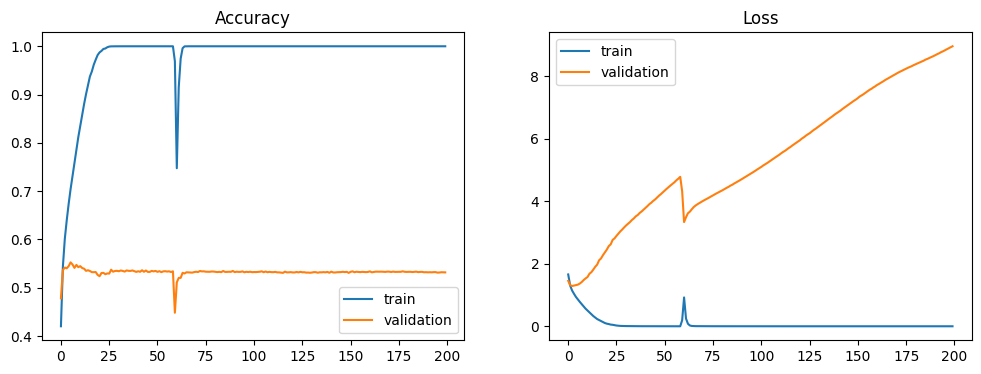

In [8]:
pca_dense = PCA(
    n_components=86,
    svd_solver="randomized",
    whiten=True,
    random_state=42,
)

X_train_dense_pca = pca_dense.fit_transform(X_train_dense)
X_test_dense_pca = pca_dense.transform(X_test_dense)

dense_pca = dense_model(
    inputs=X_train_dense_pca.shape[1],
    target=10,
)

dense_pca.summary()

dense_pca.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history_dense_pca = dense_pca.fit(
    X_train_dense_pca,
    y_train_oh,
    epochs=200,
    batch_size=256,
    verbose=1,
    validation_data=(X_test_dense_pca, y_test_oh),
)

plot_results(history_dense_pca)

## 7. Dense Network vs Compact CNN

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,362 (235.79 KB)

 Trainable params: 60,362 (235.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.4121 - loss: 1.6641 - val_accuracy: 0.5006 - val_loss: 1.4170
Epoch 2/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5506 - loss: 1.2930 - val_accuracy: 0.5774 - val_loss: 1.2148
Epoch 3/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5945 - loss: 1.1727 - val_accuracy: 0.6083 - val_loss: 1.1251
Epoch 4/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6245 - loss: 1.0876 - val_accuracy: 0.6139 - val_loss: 1.1057
Epoch 5/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6488 - loss: 1.0242 - val_accuracy: 0.6459 - val_loss: 1.0268
Epoch 6/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6594 - loss: 0.9884 - val_accuracy: 0.6546 - val_loss: 1.0016
Epoch 7/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6759 - loss: 0.9431 - val_accuracy: 0.6598 - val_loss: 0.9842
Epoch 8/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6867 - loss: 0.9136 - val_acc

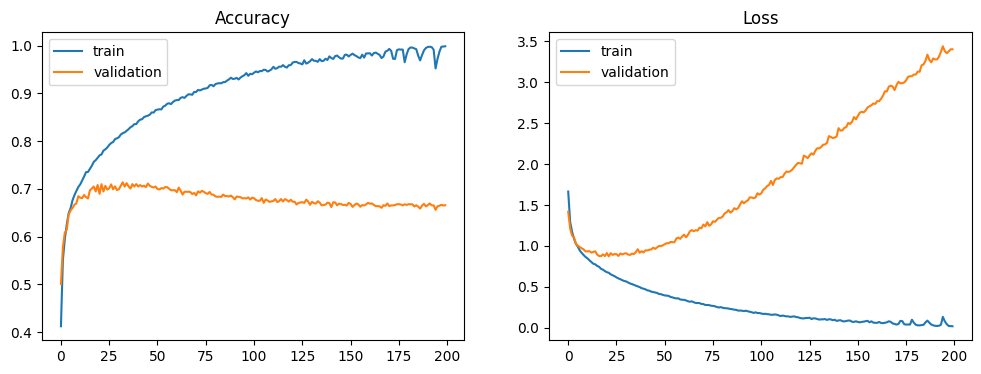

In [9]:
X_train = x_train_norm
X_test = x_test_norm


def cnn_model(input_shape=(32, 32, 3), target=10):
    return Sequential([
        Input(shape=input_shape),
        Conv2D(32, (3, 3), padding="same", activation="relu"),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), padding="same", activation="relu"),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(target, activation="softmax"),
    ])


cnn = cnn_model(input_shape=X_train.shape[1:], target=10)
cnn.summary()

cnn.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history_cnn = cnn.fit(
    X_train,
    y_train_oh,
    epochs=200,
    batch_size=256,
    verbose=1,
    validation_data=(X_test, y_test_oh),
)

plot_results(history_cnn)

## 8. Compact CNN vs VGG-Style CNNs

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,337,002 (5.10 MB)

 Trainable params: 1,337,002 (5.10 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.4014 - loss: 1.6317 - val_accuracy: 0.5113 - val_loss: 1.3229
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5915 - loss: 1.1422 - val_accuracy: 0.6267 - val_loss: 1.0542
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6782 - loss: 0.9108 - val_accuracy: 0.6847 - val_loss: 0.8928
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7249 - loss: 0.7829 - val_accuracy: 0.7197 - val_loss: 0.8039
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7664 - loss: 0.6665 - val_accuracy: 0.7251 - val_loss: 0.8042
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7993 - loss: 0.5706 - val_accuracy: 0.7315 - val_loss: 0.7798
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8291 - loss: 0.4816 - val_accuracy: 0.7453 - val_loss: 0.7700
Epoch 8/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8600 - loss: 0.3988 - val_accuracy: 

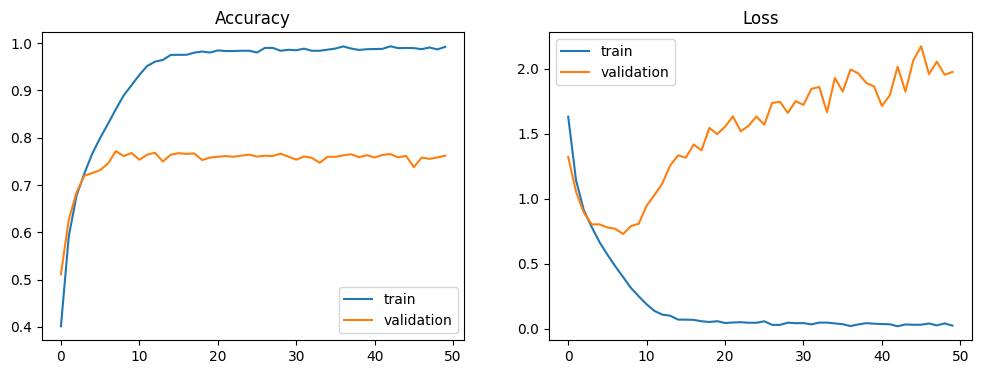

In [10]:
def vgg3(input_shape=(32, 32, 3), target=10):
    return Sequential([
        Input(shape=input_shape),

        Conv2D(32, (3, 3), padding="same", activation="relu"),
        Conv2D(32, (3, 3), padding="same", activation="relu"),
        MaxPooling2D((2, 2)),

        Conv2D(64, (3, 3), padding="same", activation="relu"),
        Conv2D(64, (3, 3), padding="same", activation="relu"),
        MaxPooling2D((2, 2)),

        Conv2D(128, (3, 3), padding="same", activation="relu"),
        Conv2D(128, (3, 3), padding="same", activation="relu"),

        Flatten(),
        Dense(128, activation="relu"),
        Dense(target, activation="softmax"),
    ])


vgg3_model = vgg3(input_shape=X_train.shape[1:], target=10)
vgg3_model.summary()

vgg3_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history_vgg3 = vgg3_model.fit(
    X_train,
    y_train_oh,
    epochs=50,
    batch_size=256,
    verbose=1,
    validation_data=(X_test, y_test_oh),
)

plot_results(history_vgg3)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,304,746 (4.98 MB)

 Trainable params: 1,304,746 (4.98 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 14s 47ms/step - accuracy: 0.1969 - loss: 2.1638 - val_accuracy: 0.2509 - val_loss: 2.1269
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3488 - loss: 1.7800 - val_accuracy: 0.3680 - val_loss: 1.7858
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4403 - loss: 1.5329 - val_accuracy: 0.4342 - val_loss: 1.5087
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5201 - loss: 1.3277 - val_accuracy: 0.5488 - val_loss: 1.2474
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5880 - loss: 1.1538 - val_accuracy: 0.5947 - val_loss: 1.1441
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6418 - loss: 1.0096 - val_accuracy: 0.6324 - val_loss: 1.0818
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6890 - loss: 0.8833 - val_accuracy: 0.6446 - val_loss: 1.0132
Epoch 8/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7293 - loss: 0.7668 - val_accuracy: 

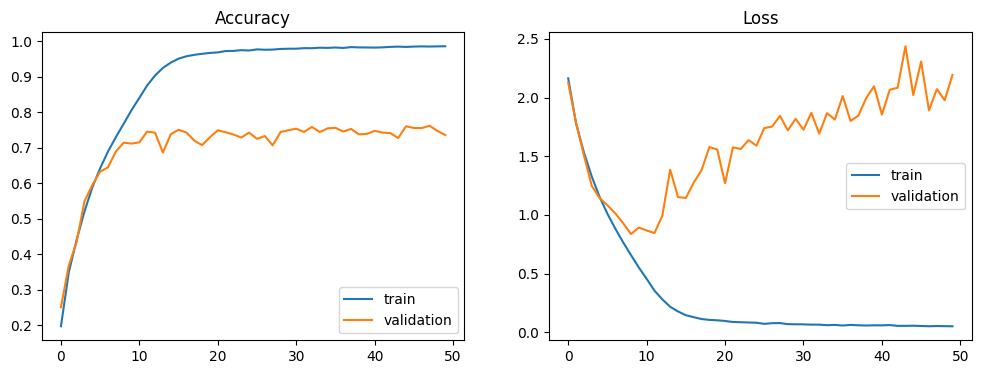

In [11]:
def build_vgg(input_shape=(32, 32, 3), filters=(32, 64, 128, 256), dense_units=128):
    model = Sequential([Input(shape=input_shape)])

    for f in filters:
        model.add(Conv2D(f, (3, 3), padding="same", activation="relu"))
        model.add(Conv2D(f, (3, 3), padding="same", activation="relu"))
        model.add(MaxPooling2D((2, 2)))

    model.add(Flatten())
    model.add(Dense(dense_units, activation="relu"))
    model.add(Dense(10, activation="softmax"))

    return model


vgg4_model = build_vgg(filters=(32, 64, 128, 256))
vgg4_model.summary()
vgg4_model.compile(loss="categorical_crossentropy", metrics=["accuracy"])

history_vgg4 = vgg4_model.fit(
    X_train,
    y_train_oh,
    epochs=50,
    batch_size=256,
    verbose=1,
    validation_data=(X_test, y_test_oh),
)

plot_results(history_vgg4)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 2, 2, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,779,178 (18.23 MB)

 Trainable params: 4,779,178 (18.23 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.1132 - loss: 2.3137 - val_accuracy: 0.1919 - val_loss: 2.1470
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.2212 - loss: 2.0769 - val_accuracy: 0.3181 - val_loss: 1.8387
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3227 - loss: 1.8109 - val_accuracy: 0.3510 - val_loss: 1.6943
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4059 - loss: 1.6055 - val_accuracy: 0.4412 - val_loss: 1.5455
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4635 - loss: 1.4551 - val_accuracy: 0.5015 - val_loss: 1.3812
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5269 - loss: 1.2999 - val_accuracy: 0.5735 - val_loss: 1.1895
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5827 - loss: 1.1567 - val_accuracy: 0.5873 - val_loss: 1.2344
Epoch 8/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6412 - loss: 1.0095 - val_accuracy: 

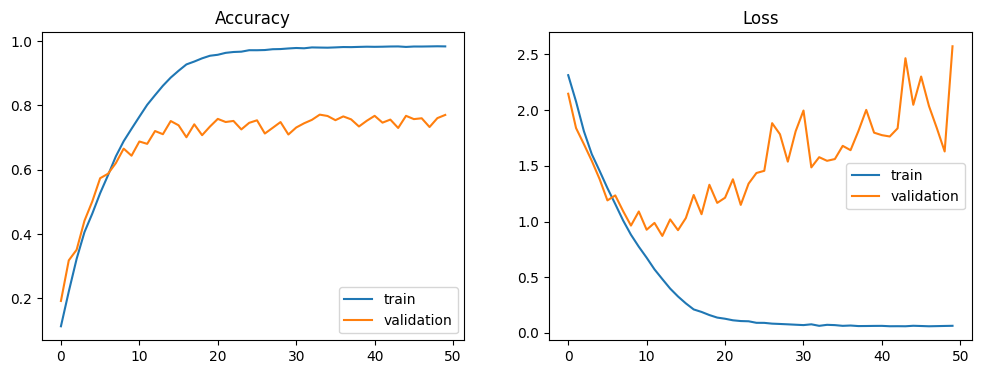

In [12]:
vgg5_model = build_vgg(filters=(32, 64, 128, 256, 512))
vgg5_model.summary()
vgg5_model.compile(loss="categorical_crossentropy", metrics=["accuracy"])

history_vgg5 = vgg5_model.fit(
    X_train,
    y_train_oh,
    epochs=50,
    batch_size=256,
    verbose=1,
    validation_data=(X_test, y_test_oh),
)

plot_results(history_vgg5)

## 9. Default Optimization vs Explicit Adam Learning Rate

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_26 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,304,746 (4.98 MB)

 Trainable params: 1,304,746 (4.98 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.2935 - loss: 1.8470 - val_accuracy: 0.3844 - val_loss: 1.7052
Epoch 2/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5026 - loss: 1.3569 - val_accuracy: 0.5702 - val_loss: 1.1917
Epoch 3/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6099 - loss: 1.0873 - val_accuracy: 0.6156 - val_loss: 1.0661
Epoch 4/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6800 - loss: 0.8938 - val_accuracy: 0.6718 - val_loss: 0.9384
Epoch 5/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7314 - loss: 0.7564 - val_accuracy: 0.7227 - val_loss: 0.7939
Epoch 6/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7728 - loss: 0.6401 - val_accuracy: 0.7437 - val_loss: 0.7477
Epoch 7/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8038 - loss: 0.5641 - val_accuracy: 0.7435 - val_loss: 0.7523
Epoch 8/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8341 - loss: 0.4734 - val_accuracy: 

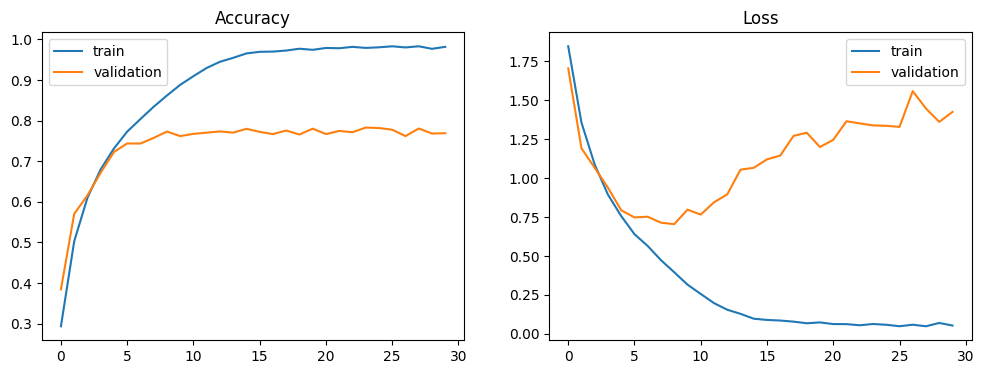

In [13]:
vgg4_adam = build_vgg(filters=(32, 64, 128, 256))
vgg4_adam.summary()

vgg4_adam.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history_vgg4_adam = vgg4_adam.fit(
    X_train,
    y_train_oh,
    epochs=30,
    batch_size=256,
    verbose=1,
    validation_data=(X_test, y_test_oh),
)

plot_results(history_vgg4_adam)

## 10. CNN With vs Without Dropout

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_34 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,304,746 (4.98 MB)

 Trainable params: 1,304,746 (4.98 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step - accuracy: 0.2991 - loss: 1.8564 - val_accuracy: 0.4404 - val_loss: 1.4813
Epoch 2/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4955 - loss: 1.3659 - val_accuracy: 0.5333 - val_loss: 1.2761
Epoch 3/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5884 - loss: 1.1401 - val_accuracy: 0.6294 - val_loss: 1.0435
Epoch 4/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6459 - loss: 0.9882 - val_accuracy: 0.6683 - val_loss: 0.9432
Epoch 5/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6908 - loss: 0.8642 - val_accuracy: 0.6934 - val_loss: 0.8636
Epoch 6/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7218 - loss: 0.7787 - val_accuracy: 0.7320 - val_loss: 0.7603
Epoch 7/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7500 - loss: 0.7038 - val_accuracy: 0.7381 - val_loss: 0.7674
Epoch 8/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7745 - loss: 0.6396 - val_accuracy: 

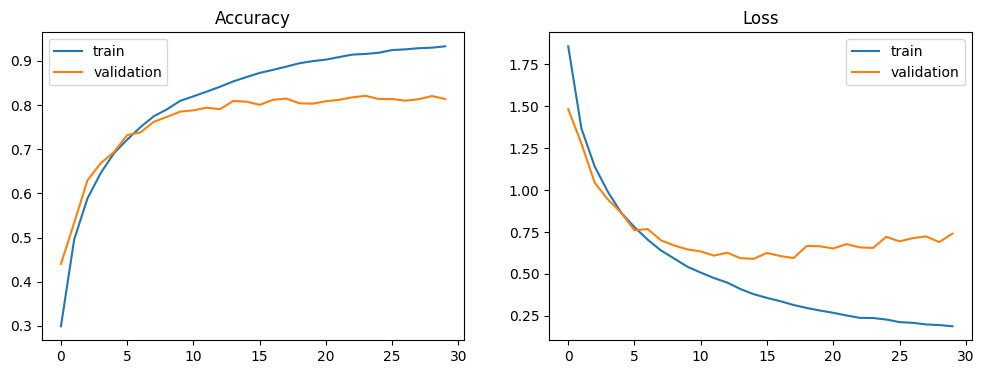

In [14]:
def vgg4_with_dropout(input_shape=(32, 32, 3), dropout_rate=0.2):
    model = Sequential([Input(shape=input_shape)])

    for f in (32, 64, 128, 256):
        model.add(Conv2D(f, (3, 3), padding="same", activation="relu"))
        model.add(Conv2D(f, (3, 3), padding="same", activation="relu"))
        model.add(MaxPooling2D((2, 2)))
        model.add(Dropout(dropout_rate))

    model.add(Flatten())
    model.add(Dense(128, activation="relu"))
    model.add(Dense(10, activation="softmax"))

    return model


vgg_dropout = vgg4_with_dropout()
vgg_dropout.summary()

vgg_dropout.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history_dropout = vgg_dropout.fit(
    X_train,
    y_train_oh,
    epochs=30,
    batch_size=256,
    verbose=1,
    validation_data=(X_test, y_test_oh),
)

plot_results(history_dropout)

## 11. Dropout vs Dropout + Batch Normalization

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_42 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 551,978 (2.11 MB)

 Trainable params: 551,274 (2.10 MB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 21s 57ms/step - accuracy: 0.4625 - loss: 1.5418 - val_accuracy: 0.1000 - val_loss: 4.3812
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6315 - loss: 1.0383 - val_accuracy: 0.1724 - val_loss: 4.7127
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7070 - loss: 0.8315 - val_accuracy: 0.6105 - val_loss: 1.1752
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7468 - loss: 0.7160 - val_accuracy: 0.7464 - val_loss: 0.7295
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7758 - loss: 0.6394 - val_accuracy: 0.7525 - val_loss: 0.7346
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7972 - loss: 0.5754 - val_accuracy: 0.7455 - val_loss: 0.7510
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8142 - loss: 0.5324 - val_accuracy: 0.7483 - val_loss: 0.7803
Epoch 8/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8301 - loss: 0.4846 - val_accuracy: 

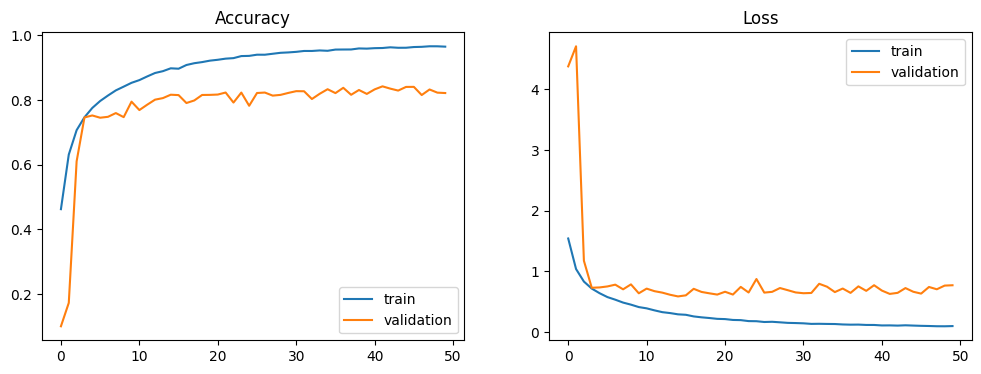

In [15]:
def vgg_dropout_bn(
    input_shape=(32, 32, 3),
    blocks=3,
    branching_factor=2,
    first_layer_filters=32,
    dropout=0.2,
    dense_layer=128,
):
    model = Sequential([Input(shape=input_shape)])

    filters = first_layer_filters

    for _ in range(blocks):
        model.add(Conv2D(filters, (3, 3), padding="same", activation="relu"))
        model.add(Conv2D(filters, (3, 3), padding="same", activation="relu"))
        model.add(MaxPooling2D((2, 2)))
        model.add(BatchNormalization())
        model.add(Dropout(dropout))

        filters = int(filters * branching_factor)

    model.add(Flatten())

    if dense_layer > 0:
        model.add(Dense(dense_layer, activation="relu"))
        model.add(BatchNormalization())
        model.add(Dropout(dropout))

    model.add(Dense(10))
    model.add(Activation("softmax"))

    return model


vgg_bn = vgg_dropout_bn(blocks=3)
vgg_bn.summary()

vgg_bn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history_bn = vgg_bn.fit(
    X_train,
    y_train_oh,
    epochs=50,
    batch_size=256,
    verbose=1,
    validation_data=(X_test, y_test_oh),
)

plot_results(history_bn)

## 12. Original Training vs Mirrored Training

Original training set: (50000, 32, 32, 3)
Mirrored training set: (100000, 32, 32, 3)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_48 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 551,978 (2.11 MB)

 Trainable params: 551,274 (2.10 MB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - accuracy: 0.5628 - loss: 1.2402 - val_accuracy: 0.1169 - val_loss: 5.9605
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7294 - loss: 0.7688 - val_accuracy: 0.6823 - val_loss: 0.9484
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7803 - loss: 0.6285 - val_accuracy: 0.7328 - val_loss: 0.7645
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8098 - loss: 0.5461 - val_accuracy: 0.7455 - val_loss: 0.7502
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8279 - loss: 0.4922 - val_accuracy: 0.7955 - val_loss: 0.6037
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8454 - loss: 0.4437 - val_accuracy: 0.8209 - val_loss: 0.5254
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8574 - loss: 0.4081 - val_accuracy: 0.7960 - val_loss: 0.6116
Epoch 8/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8673 - loss: 0.3766 - val_accuracy: 

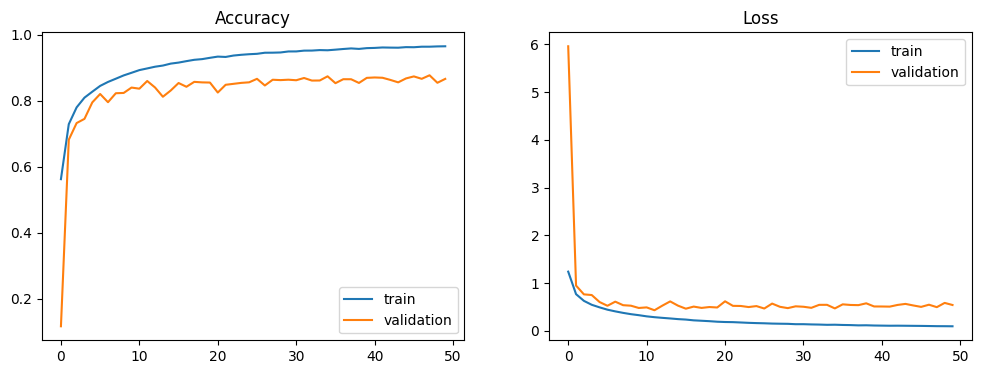

In [16]:
X_train_mirror = np.concatenate(
    [X_train, X_train[:, :, ::-1]],
    axis=0,
)

y_train_mirror = np.concatenate(
    [y_train_oh, y_train_oh],
    axis=0,
)

print("Original training set:", X_train.shape)
print("Mirrored training set:", X_train_mirror.shape)

vgg_mirror = vgg_dropout_bn(blocks=3)
vgg_mirror.summary()

vgg_mirror.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history_mirror = vgg_mirror.fit(
    X_train_mirror,
    y_train_mirror,
    epochs=50,
    batch_size=256,
    verbose=1,
    validation_data=(X_test, y_test_oh),
)

plot_results(history_mirror)

## 13. Original vs Mirrored vs Ensemble Prediction

In [17]:
y_test_class = y_test_raw.ravel()

pred_original = vgg_mirror.predict(X_test, verbose=0)
pred_mirrored = vgg_mirror.predict(X_test[:, :, ::-1], verbose=0)

accuracy_original = accuracy_score(
    y_test_class,
    np.argmax(pred_original, axis=1),
)

accuracy_mirrored = accuracy_score(
    y_test_class,
    np.argmax(pred_mirrored, axis=1),
)

avg_pred = (pred_original + pred_mirrored) / 2.0

accuracy_combined = accuracy_score(
    y_test_class,
    np.argmax(avg_pred, axis=1),
)

print("Original test accuracy: {:.4f}".format(accuracy_original))
print("Mirrored test accuracy: {:.4f}".format(accuracy_mirrored))
print("Combined test accuracy: {:.4f}".format(accuracy_combined))

Original test accuracy: 0.8667
Mirrored test accuracy: 0.8698
Combined test accuracy: 0.8814


### Inspect examples corrected by mirrored prediction

Number of corrected examples: 324

Test example: 7455
True class: car
Original probabilities:
0.0000 0.0146 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.9854
Mirrored probabilities:
0.0000 0.9995 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0005
Average probabilities:
0.0000 0.5070 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.4930


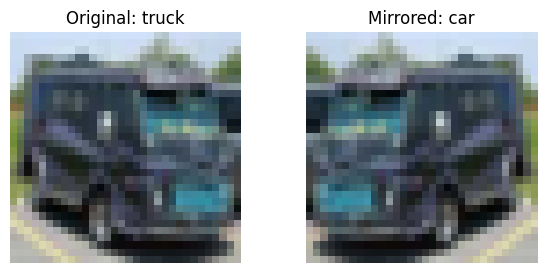


Test example: 4408
True class: airplane
Original probabilities:
0.1493 0.1143 0.6311 0.0010 0.0262 0.0002 0.0009 0.0001 0.0761 0.0008
Mirrored probabilities:
0.8759 0.0268 0.0821 0.0094 0.0001 0.0006 0.0016 0.0003 0.0031 0.0002
Average probabilities:
0.5126 0.0706 0.3566 0.0052 0.0131 0.0004 0.0013 0.0002 0.0396 0.0005


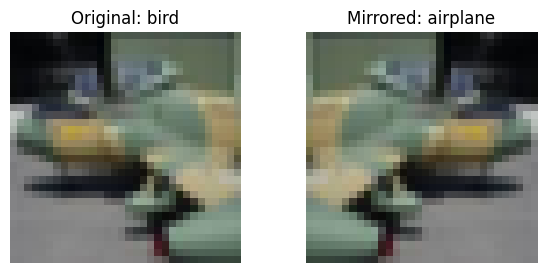


Test example: 6206
True class: dog
Original probabilities:
0.0000 0.0000 0.1350 0.5173 0.0000 0.3060 0.0418 0.0000 0.0000 0.0000
Mirrored probabilities:
0.0000 0.0000 0.0015 0.0471 0.0000 0.9513 0.0001 0.0000 0.0000 0.0000
Average probabilities:
0.0000 0.0000 0.0682 0.2822 0.0000 0.6286 0.0209 0.0000 0.0000 0.0000


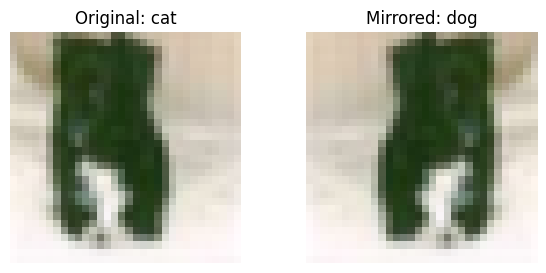


Test example: 818
True class: ship
Original probabilities:
0.7096 0.0473 0.0010 0.0150 0.0046 0.0003 0.0020 0.0000 0.1214 0.0988
Mirrored probabilities:
0.0073 0.0490 0.0006 0.0008 0.0063 0.0001 0.0002 0.0000 0.8766 0.0591
Average probabilities:
0.3584 0.0481 0.0008 0.0079 0.0055 0.0002 0.0011 0.0000 0.4990 0.0790


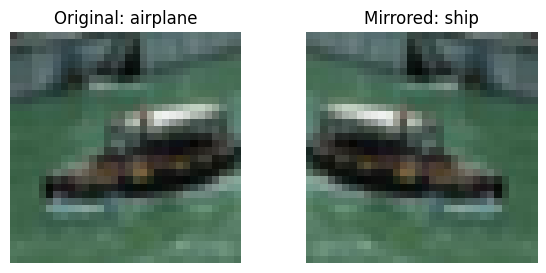


Test example: 4376
True class: horse
Original probabilities:
0.0037 0.0000 0.5233 0.0002 0.0539 0.0006 0.0007 0.4058 0.0119 0.0000
Mirrored probabilities:
0.0115 0.0000 0.0657 0.0001 0.0412 0.0000 0.0002 0.8807 0.0004 0.0001
Average probabilities:
0.0076 0.0000 0.2945 0.0002 0.0475 0.0003 0.0004 0.6433 0.0062 0.0001


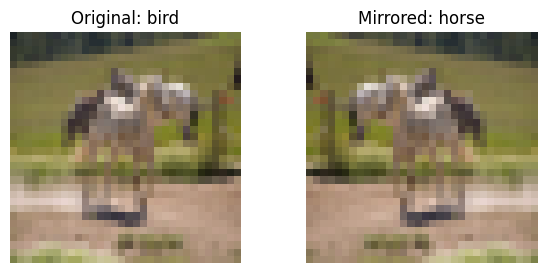

In [18]:
def print_array(values):
    print(" ".join("{:.4f}".format(v) for v in values))


class_names = [
    "airplane", "car", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

pred_original_class = np.argmax(pred_original, axis=1)
pred_combined_class = np.argmax(avg_pred, axis=1)

corrected = np.where(
    (y_test_class == pred_combined_class)
    & (y_test_class != pred_original_class)
)[0]

print("Number of corrected examples:", len(corrected))

if len(corrected) > 0:
    rng = np.random.default_rng(42)
    selected = rng.choice(
        corrected,
        size=min(5, len(corrected)),
        replace=False,
    )

    for idx in selected:
        fig, ax = plt.subplots(1, 2, figsize=(7, 3))

        ax[0].imshow(X_test[idx])
        ax[0].set_title("Original: " + class_names[pred_original_class[idx]])
        ax[0].axis("off")

        ax[1].imshow(X_test[idx, :, ::-1])
        ax[1].set_title(
            "Mirrored: " + class_names[np.argmax(pred_mirrored[idx])]
        )
        ax[1].axis("off")

        print("\nTest example:", idx)
        print("True class:", class_names[y_test_class[idx]])
        print("Original probabilities:")
        print_array(pred_original[idx])
        print("Mirrored probabilities:")
        print_array(pred_mirrored[idx])
        print("Average probabilities:")
        print_array(avg_pred[idx])

        plt.show()

## 14. Fixed Learning Rate vs Learning-Rate Scheduling

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_54 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_56 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_58 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_59 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_60 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 2, 2, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 128)            │           51

 Total params: 1,307,178 (4.99 MB)

 Trainable params: 1,305,962 (4.98 MB)

 Non-trainable params: 1,216 (4.75 KB)

Epoch 1/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 39ms/step - accuracy: 0.5016 - loss: 1.3823 - val_accuracy: 0.4672 - val_loss: 1.6037 - learning_rate: 0.0050
Epoch 2/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7101 - loss: 0.8210 - val_accuracy: 0.6623 - val_loss: 1.0942 - learning_rate: 0.0050
Epoch 3/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7763 - loss: 0.6426 - val_accuracy: 0.7530 - val_loss: 0.7342 - learning_rate: 0.0050
Epoch 4/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8109 - loss: 0.5442 - val_accuracy: 0.7502 - val_loss: 0.7461 - learning_rate: 0.0050
Epoch 5/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8332 - loss: 0.4798 - val_accuracy: 0.7981 - val_loss: 0.6179 - learning_rate: 0.0050
Epoch 6/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8506 - loss: 0.4283 - val_accuracy: 0.8146 - val_loss: 0.5561 - learning_rate: 0.0050
Epoch 7/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8666 - loss: 0.3841 

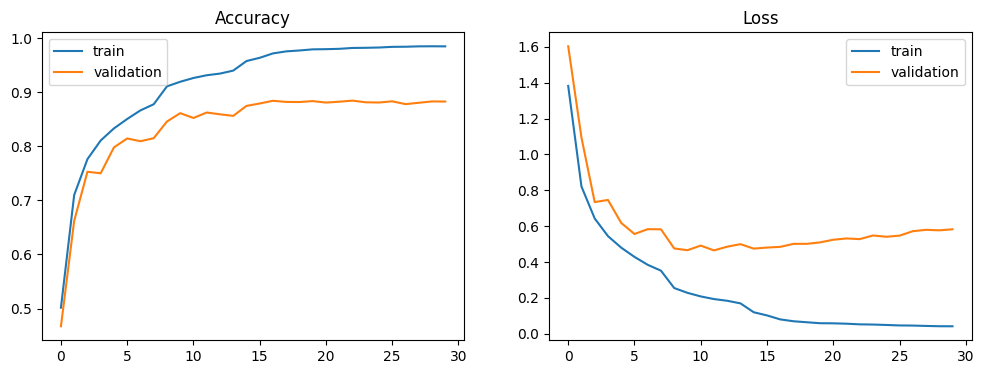

In [19]:
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    verbose=1,
    min_lr=0.0005,
)

vgg_lr = vgg_dropout_bn(blocks=4)
vgg_lr.summary()

vgg_lr.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history_lr = vgg_lr.fit(
    X_train_mirror,
    y_train_mirror,
    epochs=30,
    batch_size=256,
    verbose=1,
    validation_data=(X_test, y_test_oh),
    callbacks=[reduce_lr],
)

plot_results(history_lr)

## 15. Generator-Based Augmentation Comparison

### 15.1 Featurewise standardization + rotation + translation + horizontal flip

The training generator is fitted to the training data so that featurewise statistics are defined. The validation generator receives the same statistics.

Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 45s 179ms/step - accuracy: 0.3541 - loss: 1.8034 - val_accuracy: 0.2103 - val_loss: 2.6015 - learning_rate: 0.0010
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.4824 - loss: 1.4339
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
196/196 ━━━━━━━━━━━━━━━━━━━━ 26s 133ms/step - accuracy: 0.5027 - loss: 1.3857 - val_accuracy: 0.4423 - val_loss: 1.7218 - learning_rate: 0.0010
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 26s 132ms/step - accuracy: 0.5823 - loss: 1.1710 - val_accuracy: 0.5532 - val_loss: 1.2872 - learning_rate: 5.0000e-04
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 26s 132ms/step - accuracy: 0.6223 - loss: 1.0628 - val_accuracy: 0.6877 - val_loss: 0.8945 - learning_rate: 5.0000e-04
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 26s 133ms/step - accuracy: 0.6510 - loss: 0.9894 - val_accuracy: 0.6806 - val_loss: 0.9299 - learning_rate: 5.0000e-04
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 26s 132ms/step - acc

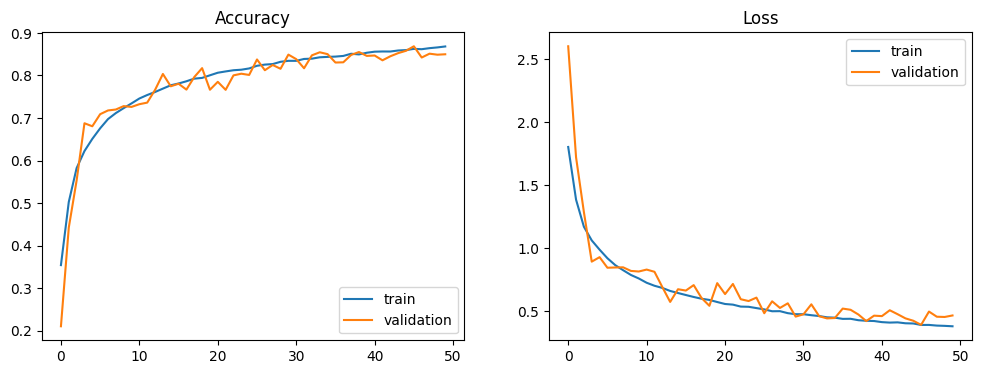

In [20]:
train_datagen_standardized = ImageDataGenerator(
    featurewise_center=True,
    featurewise_std_normalization=True,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
)

train_datagen_standardized.fit(X_train)

test_datagen_standardized = ImageDataGenerator(
    featurewise_center=True,
    featurewise_std_normalization=True,
)

test_datagen_standardized.mean = train_datagen_standardized.mean
test_datagen_standardized.std = train_datagen_standardized.std

train_generator_standardized = train_datagen_standardized.flow(
    X_train,
    y_train_oh,
    batch_size=256,
)

test_generator_standardized = test_datagen_standardized.flow(
    X_test,
    y_test_oh,
    batch_size=256,
    shuffle=False,
)

model_generator_standardized = vgg_dropout_bn(blocks=4)
model_generator_standardized.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history_generator_standardized = model_generator_standardized.fit(
    train_generator_standardized,
    epochs=50,
    verbose=1,
    validation_data=test_generator_standardized,
    callbacks=[reduce_lr],
)

plot_results(history_generator_standardized)

### 15.2 Rescaling inside `ImageDataGenerator`

This variant starts from the original `uint8` CIFAR-10 images so that `rescale=1/255` is applied exactly once.

Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 45s 174ms/step - accuracy: 0.3630 - loss: 1.8044 - val_accuracy: 0.1000 - val_loss: 4.6912 - learning_rate: 0.0010
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.4794 - loss: 1.4469
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
196/196 ━━━━━━━━━━━━━━━━━━━━ 26s 130ms/step - accuracy: 0.5020 - loss: 1.3807 - val_accuracy: 0.1004 - val_loss: 6.6280 - learning_rate: 0.0010
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 26s 130ms/step - accuracy: 0.5828 - loss: 1.1699 - val_accuracy: 0.2763 - val_loss: 2.9529 - learning_rate: 5.0000e-04
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 26s 131ms/step - accuracy: 0.6156 - loss: 1.0799 - val_accuracy: 0.5938 - val_loss: 1.2104 - learning_rate: 5.0000e-04
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 26s 131ms/step - accuracy: 0.6430 - loss: 1.0093 - val_accuracy: 0.6295 - val_loss: 1.1716 - learning_rate: 5.0000e-04
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 26s 130ms/step - acc

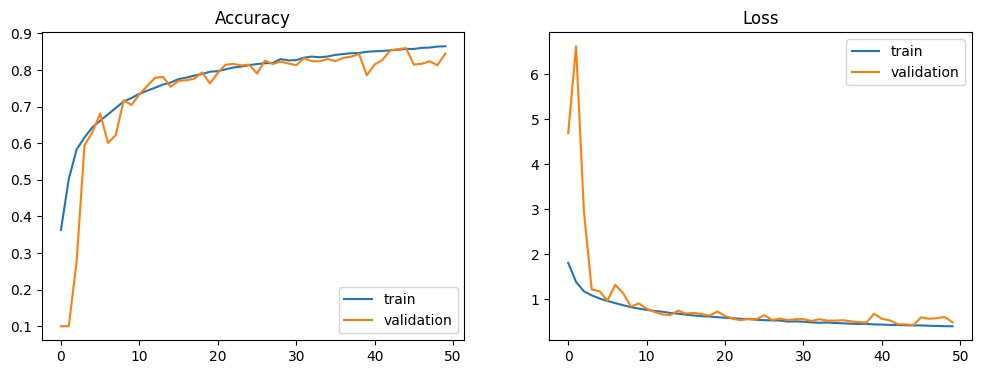

In [21]:
train_datagen_rescale = ImageDataGenerator(
    rescale=1.0 / 255.0,
    featurewise_center=False,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
)

test_datagen_rescale = ImageDataGenerator(
    rescale=1.0 / 255.0,
)

train_generator_rescale = train_datagen_rescale.flow(
    x_train_raw,
    y_train_oh,
    batch_size=256,
)

test_generator_rescale = test_datagen_rescale.flow(
    x_test_raw,
    y_test_oh,
    batch_size=256,
    shuffle=False,
)

model_generator_rescale = vgg_dropout_bn(blocks=4)
model_generator_rescale.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history_generator_rescale = model_generator_rescale.fit(
    train_generator_rescale,
    epochs=50,
    verbose=1,
    validation_data=test_generator_rescale,
    callbacks=[reduce_lr],
)

plot_results(history_generator_rescale)

### 15.3 Small shifts + horizontal flip

Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 45s 179ms/step - accuracy: 0.4075 - loss: 1.6735 - val_accuracy: 0.1000 - val_loss: 7.2250 - learning_rate: 0.0010
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.5420 - loss: 1.2795
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
196/196 ━━━━━━━━━━━━━━━━━━━━ 24s 121ms/step - accuracy: 0.5621 - loss: 1.2210 - val_accuracy: 0.1710 - val_loss: 6.1740 - learning_rate: 0.0010
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 24s 121ms/step - accuracy: 0.6445 - loss: 0.9967 - val_accuracy: 0.4464 - val_loss: 1.9066 - learning_rate: 5.0000e-04
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 24s 120ms/step - accuracy: 0.6836 - loss: 0.8925 - val_accuracy: 0.7064 - val_loss: 0.8407 - learning_rate: 5.0000e-04
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 24s 121ms/step - accuracy: 0.7085 - loss: 0.8260 - val_accuracy: 0.7097 - val_loss: 0.8471 - learning_rate: 5.0000e-04
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 24s 125ms/step - acc

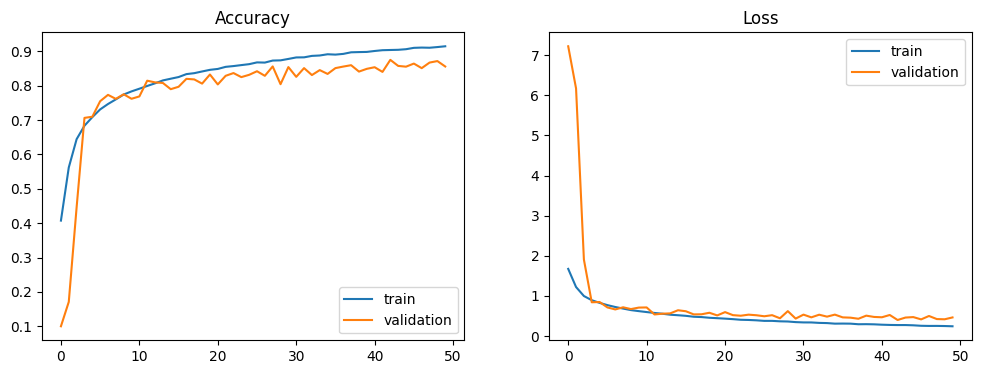

In [22]:
train_datagen_shift = ImageDataGenerator(
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
)

train_generator_shift = train_datagen_shift.flow(
    X_train,
    y_train_oh,
    batch_size=256,
    shuffle=False,
)

model_generator_shift = vgg_dropout_bn(blocks=4)
model_generator_shift.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history_generator_shift = model_generator_shift.fit(
    train_generator_shift,
    epochs=50,
    verbose=1,
    validation_data=(X_test, y_test_oh),
    callbacks=[reduce_lr],
)

plot_results(history_generator_shift)

## 16. Individual Augmentation-Layer Comparison

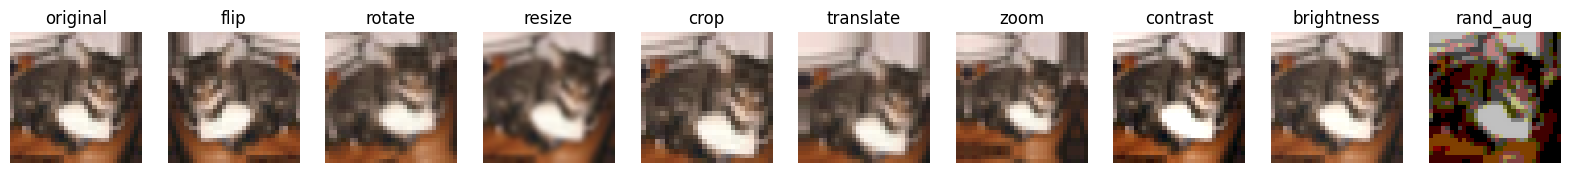

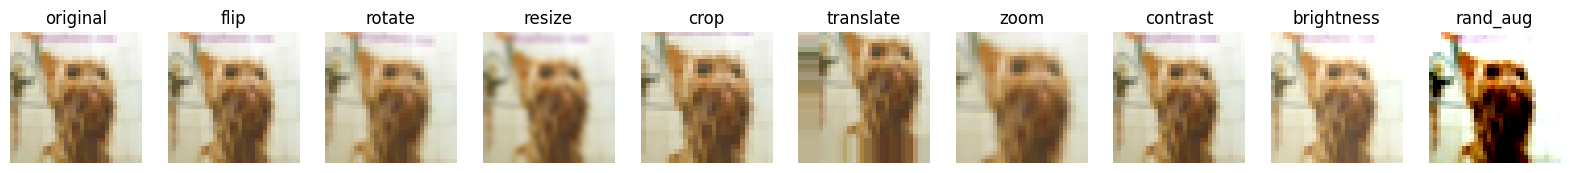

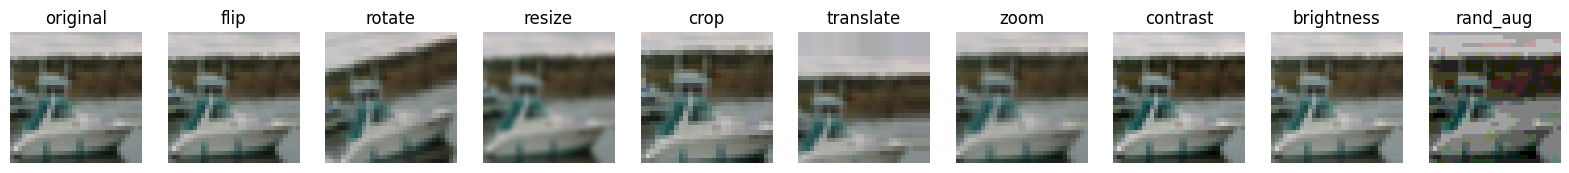

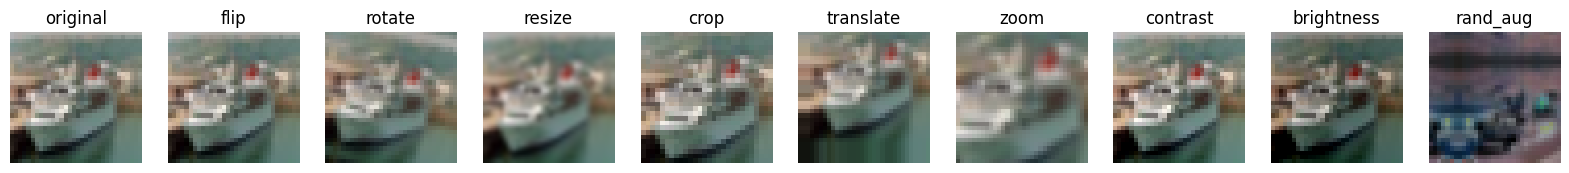

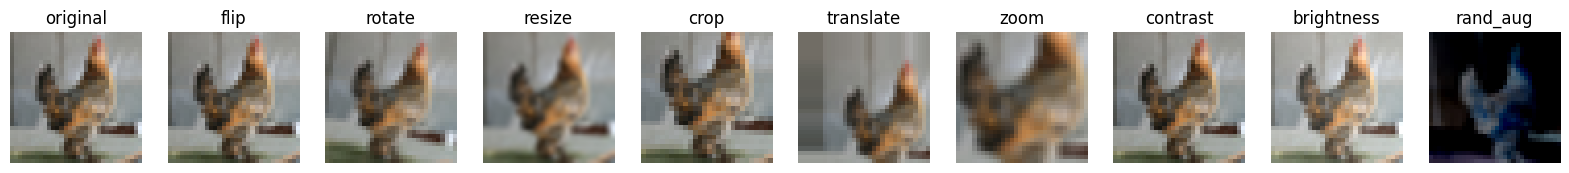

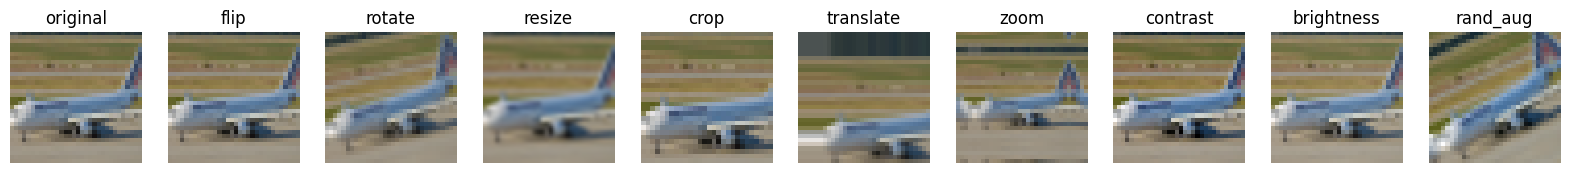

In [23]:
rng = np.random.default_rng(42)
selected = rng.integers(0, X_train.shape[0], size=6)
batch = X_train[selected]

augmentation_models = {
    "flip": Sequential([RandomFlip("horizontal")]),
    "rotate": Sequential([RandomRotation(0.05)]),
    "resize": Sequential([Resizing(64, 64)]),
    "crop": Sequential([RandomCrop(28, 28)]),
    "translate": Sequential([
        RandomTranslation(0.2, 0.2, fill_mode="nearest")
    ]),
    "zoom": Sequential([RandomZoom(0.4)]),
    "contrast": Sequential([
        RandomContrast(0.2, value_range=(0, 1))
    ]),
    "brightness": Sequential([
        RandomBrightness(0.2, value_range=(0, 1))
    ]),
    "rand_aug": Sequential([
        RandAugment(value_range=(0, 1))
    ]),
}

for image in batch:
    fig, ax = plt.subplots(
        1,
        len(augmentation_models) + 1,
        figsize=(20, 4),
    )

    ax[0].imshow(image)
    ax[0].set_title("original")
    ax[0].axis("off")

    for j, (name, aug_model) in enumerate(augmentation_models.items(), start=1):
        augmented = aug_model(image[None, ...], training=True)
        ax[j].imshow(np.clip(augmented[0].numpy(), 0, 1))
        ax[j].set_title(name)
        ax[j].axis("off")

    plt.show()

## 17. Individual vs Combined Augmentation

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_2               │ ?                      │   0 (unbuilt) │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

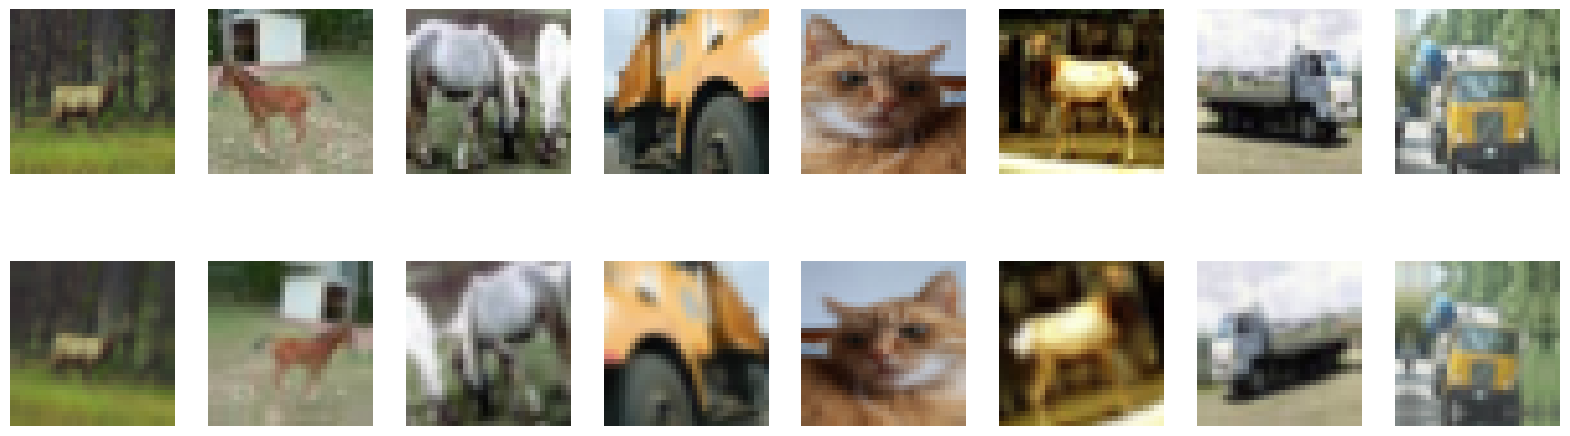

In [24]:
augmentation_layers = [
    RandomFlip("horizontal"),
    RandomRotation(0.05),
    RandomZoom(0.2),
]

augmentation_model = Sequential(augmentation_layers)
augmentation_model.summary()

selected = rng.integers(0, X_train.shape[0], size=8)
batch = X_train[selected]

augmented_batch = augmentation_model(batch, training=True)

fig, ax = plt.subplots(2, len(selected), figsize=(20, 6))

for i in range(len(selected)):
    ax[0, i].imshow(batch[i])
    ax[0, i].axis("off")

    ax[1, i].imshow(np.clip(augmented_batch[i].numpy(), 0, 1))
    ax[1, i].axis("off")

plt.show()

## 18. Baseline CNN vs On-the-Fly Augmented CNN

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_2               │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_86 (Conv2D)              │ (None, 32, 32, 50)     │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_87 (Conv2D)              │ (None, 32, 32, 50)     │        22,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_43 (MaxPooling2D) │ (None, 16, 16, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 16, 16, 50)     │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 16, 16, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_88 (Conv2D)              │ (None, 16, 16, 100)    │        45,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_89 (Conv2D)              │ (None, 16, 16, 100)    │        90,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_44 (MaxPooling2D) │ (None, 8, 8, 100)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 8, 8, 100)      │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 8, 8, 100)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_90 (Conv2D)              │ (None, 8, 8, 200)      │       180,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_91 (Conv2D)              │ (None, 8, 8, 200)      │       360,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_45 (MaxPooling2D) │ (None, 4, 4, 200)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 4, 4, 200)      │           800 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 4, 4, 200)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 100)            │       320,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,022,460 (3.90 MB)

 Trainable params: 1,021,560 (3.90 MB)

 Non-trainable params: 900 (3.52 KB)

Epoch 1/100
1000/1000 - 16s - 16ms/step - accuracy: 0.5142 - loss: 1.3702 - val_accuracy: 0.6238 - val_loss: 1.1084
Epoch 2/100
1000/1000 - 10s - 10ms/step - accuracy: 0.6793 - loss: 0.9153 - val_accuracy: 0.7222 - val_loss: 0.8214
Epoch 3/100
1000/1000 - 10s - 10ms/step - accuracy: 0.7311 - loss: 0.7747 - val_accuracy: 0.7204 - val_loss: 0.8367
Epoch 4/100
1000/1000 - 10s - 10ms/step - accuracy: 0.7589 - loss: 0.6963 - val_accuracy: 0.7587 - val_loss: 0.7246
Epoch 5/100
1000/1000 - 10s - 10ms/step - accuracy: 0.7795 - loss: 0.6351 - val_accuracy: 0.7824 - val_loss: 0.6572
Epoch 6/100
1000/1000 - 10s - 10ms/step - accuracy: 0.7975 - loss: 0.5869 - val_accuracy: 0.8107 - val_loss: 0.5582
Epoch 7/100
1000/1000 - 10s - 10ms/step - accuracy: 0.8083 - loss: 0.5533 - val_accuracy: 0.8119 - val_loss: 0.5604
Epoch 8/100
1000/1000 - 10s - 10ms/step - accuracy: 0.8191 - loss: 0.5232 - val_accuracy: 0.8310 - val_loss: 0.4965
Epoch 9/100
1000/1000 - 10s - 10ms/step - accuracy: 0.8301 - loss: 0.493

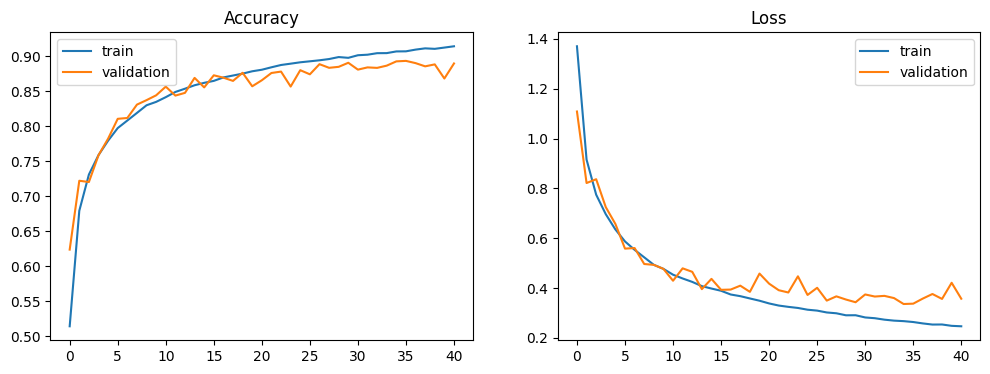

In [25]:
early_stopping = EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True,
)


def augmented_cnn(
    input_shape,
    conv_units,
    dense_units,
    out_units,
    augmentation_layers=None,
    dropout_rate=0.2,
):
    model = Sequential([Input(shape=input_shape)])

    if augmentation_layers is not None:
        for layer in augmentation_layers:
            model.add(layer)

    for filters in conv_units:
        model.add(Conv2D(filters, (3, 3), activation="relu", padding="same"))
        model.add(Conv2D(filters, (3, 3), activation="relu", padding="same"))
        model.add(MaxPooling2D((2, 2)))
        model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))

    model.add(Flatten())
    model.add(Dense(dense_units, activation="relu"))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(out_units, activation="softmax"))

    return model


num_classes = int(np.max(y_train_raw) + 1)

model_augmented = augmented_cnn(
    input_shape=X_train.shape[1:],
    conv_units=[50, 100, 200],
    dense_units=100,
    out_units=num_classes,
    augmentation_layers=augmentation_layers,
    dropout_rate=0.25,
)

model_augmented.summary()

model_augmented.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

X_train_aug = np.concatenate(
    [X_train, X_train[:, :, ::-1]],
    axis=0,
)

y_train_aug = np.concatenate(
    [y_train_raw, y_train_raw],
    axis=0,
)

start_train = time.time()

history_augmented = model_augmented.fit(
    X_train_aug,
    y_train_aug,
    epochs=100,
    batch_size=100,
    verbose=2,
    validation_data=(X_test, y_test_raw),
    callbacks=[early_stopping],
)

end_train = time.time()

print("Elapsed training time: {:.4f} seconds".format(end_train - start_train))
plot_results(history_augmented)

## 19. Standard vs Mirrored vs Augmented Test-Time Prediction

In [26]:
pred1 = model_augmented.predict(X_test, verbose=0)
pred2 = model_augmented.predict(X_test[:, :, ::-1], verbose=0)

y_test_flat = y_test_raw.ravel()

print(
    "Model accuracy on original test set: {:.4f}".format(
        accuracy_score(y_test_flat, np.argmax(pred1, axis=1))
    )
)

print(
    "Model accuracy on mirrored test set: {:.4f}".format(
        accuracy_score(y_test_flat, np.argmax(pred2, axis=1))
    )
)

avg_pred = (pred1 + pred2) / 2.0

print(
    "Combined original + mirrored accuracy: {:.4f}".format(
        accuracy_score(y_test_flat, np.argmax(avg_pred, axis=1))
    )
)

# Add stochastic predictions produced by the augmentation pipeline.
pred_tta = pred1 + pred2

for _ in range(1):
    X_test_aug = augmentation_model(X_test, training=True)
    X_test_mirror_aug = augmentation_model(X_test[:, :, ::-1], training=True)

    pred_tta += model_augmented.predict(X_test_aug, verbose=0)
    pred_tta += model_augmented.predict(X_test_mirror_aug, verbose=0)

print(
    "Accuracy with augmented test-time ensemble: {:.4f}".format(
        accuracy_score(y_test_flat, np.argmax(pred_tta, axis=1))
    )
)

Model accuracy on original test set: 0.8935
Model accuracy on mirrored test set: 0.8898
Combined original + mirrored accuracy: 0.9001
Accuracy with augmented test-time ensemble: 0.9019


### Reference augmentation results

A prior run of the augmentation model produced:
- original test accuracy: **0.8906**
- mirrored test accuracy: **0.8925**
- original + mirrored ensemble: **0.8990**
- augmented test-time ensemble: **0.9006**

## 20. CIFAR-10 Comparison Summary

CIFAR-10 makes the representation gap clear. Classical pixel-based methods and dense networks struggle to capture local image structure, while CNNs improve substantially. Deeper CNNs, dropout, batch normalization, mirrored examples, scheduled learning rates, and augmentation provide additional ways to improve generalization and robustness.